In [1]:
try:
    import xgboost
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])


# AQI Forecasting — XGBoost Model
**Dataset:** `AnandVihar_AQI_hourly_features.csv` (hourly, engineered by EDA notebook)  
**Target:** Next-hour AQI  
**Model:** XGBoost with lag + rolling + cyclic calendar + pollutant + weather features  

EDA findings used here:
- **Granularity:** Hourly preferred (43 k rows → better tree generalisation)
- **Key features:** PM25, PM10, CO, NOx (r > 0.6 with AQI); O3 & WS negative correlators
- **Multicollinearity:** NO↔NOx (r=0.99), PM25↔PM10 — kept but XGBoost handles this natively
- **Seasonality:** Strong annual + daily cycle → encoded via Hour_sin/cos, Month_sin/cos
- **Split:** 70/15/15 time-based chronological (no random splits — data leakage risk)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings, os
warnings.filterwarnings('ignore')

# ── Config — only change these paths ──────────────────────────
INPUT_FILE   = r'D:\AQI_Project_new\data\clean\AnandVihar_AQI_cleaned.csv'
SAVE_DIR     = r'D:\AQI_Project_new\XGBOOST\saved_models'
IMAGE_DIR    = 'images'
STATION_NAME = 'AnandVihar'
RANDOM_SEED  = 42

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(SAVE_DIR,  exist_ok=True)

print('Libraries loaded successfully.')
print(f'XGBoost version: {xgb.__version__}')
print(f'Station: {STATION_NAME}')


Libraries loaded successfully.
XGBoost version: 2.1.3
Station: AnandVihar


## 1. Load & Preprocess Data

In [3]:
# ── 1. Load hourly feature-engineered CSV (output of EDA §11) ─
df = pd.read_csv(INPUT_FILE, parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'Shape      : {df.shape}')
print(f'Date range : {df["Timestamp"].min()}  →  {df["Timestamp"].max()}')
print(f'Columns    : {df.columns.tolist()}')
print(f'Nulls      : {df.isnull().sum().sum()}')
df.head(3)


Shape      : (43812, 20)
Date range : 2021-01-01 12:00:00  →  2025-12-31 23:00:00
Columns    : ['Timestamp', 'NO', 'NOx', 'Benzene', 'Toluene', 'AT', 'RH', 'WS', 'WD', 'SR', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'AQI', 'AQI_Category']
Nulls      : 0


,Timestamp,NO,NOx,Benzene,Toluene,AT,RH,WS,WD,SR,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
0,2021-01-01 12:00:00,131.36,169.79,10.57,93.7,14.3,74.83,0.49,142.19,155.31,972.25,431.5,416.35,132.02,36.03,14.61,127.97,56.31,127.97,Moderate
1,2021-01-01 13:00:00,131.36,169.79,10.57,93.7,14.3,74.83,0.49,142.19,155.31,972.25,431.5,416.35,132.02,36.03,14.61,126.04,56.21,126.04,Moderate
2,2021-01-01 14:00:00,131.36,169.79,10.57,93.7,14.3,74.83,0.49,142.19,155.31,972.25,431.5,416.35,132.02,36.03,14.61,123.50,57.75,123.50,Moderate


## 2. Feature Engineering


In [4]:
# ── 2. Feature engineering on hourly data ─────────────────────
# The EDA export already contains:
#   • AQI_lag_1h … AQI_lag_48h
#   • AQI_roll_mean_3/6/24h, AQI_roll_std_3/6/24h
#   • Hour_sin/cos, Month_sin/cos, IsWeekend, Season_Enc, AQI_Category_Enc
# We add a few extra lags and then define the final feature list.

df_feat = df.copy()

# Additional hourly lags not in the EDA export
for lag in [72, 168]:          # 3-day, 1-week
    col = f'AQI_lag_{lag}h'
    if col not in df_feat.columns:
        df_feat[col] = df_feat['AQI'].shift(lag)

# Day-of-year cyclic (annual seasonality signal for XGBoost)
if 'DayOfYear' not in df_feat.columns:
    df_feat['DayOfYear'] = df_feat['Timestamp'].dt.dayofyear
df_feat['doy_sin'] = np.sin(2 * np.pi * df_feat['DayOfYear'] / 365)
df_feat['doy_cos'] = np.cos(2 * np.pi * df_feat['DayOfYear'] / 365)

# Drop columns that are not model inputs
DROP_COLS = ['Timestamp', 'AQI_Category', 'Season', 'AQI_Category_Enc']
lag_roll_cols = [c for c in df_feat.columns if 'lag' in c or 'roll' in c]

# Feature list = everything except target and drop cols
feature_cols = [c for c in df_feat.columns
                if c not in DROP_COLS + ['AQI']
                and df_feat[c].dtype in [np.float64, np.int64, float, int]]

# Drop rows where any lag/roll feature is NaN (first ~168 rows)
df_model = df_feat.dropna(subset=lag_roll_cols).copy()

X = df_model[feature_cols]
y = df_model['AQI']

print(f'Feature matrix : {X.shape}')
print(f'Null count in X: {X.isnull().sum().sum()}')
print(f'\nFeatures ({len(feature_cols)}):')
for f in feature_cols:
    print(f'  • {f}')


Feature matrix : (43644, 22)
Null count in X: 0

Features (22):
  • NO
  • NOx
  • Benzene
  • Toluene
  • AT
  • RH
  • WS
  • WD
  • SR
  • BP
  • PM25
  • PM10
  • NO2
  • SO2
  • NH3
  • CO
  • O3
  • AQI_lag_72h
  • AQI_lag_168h
  • DayOfYear
  • doy_sin
  • doy_cos


## 3. Train / Validation / Test Split (70 / 15 / 15 — Temporal)


In [5]:
# ── 3. Chronological 70/15/15 split ───────────────────────────
# EDA §10.7: always use time-based splits to avoid data leakage
n = len(df_model)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_model.iloc[:train_end]
val_df   = df_model.iloc[train_end:val_end]
test_df  = df_model.iloc[val_end:]

X_train, y_train = train_df[feature_cols], train_df['AQI']
X_val,   y_val   = val_df[feature_cols],   val_df['AQI']
X_test,  y_test  = test_df[feature_cols],  test_df['AQI']

print(f'Train : {len(train_df):,} rows  '
      f'({train_df["Timestamp"].iloc[0].date()} → {train_df["Timestamp"].iloc[-1].date()})')
print(f'Val   : {len(val_df):,} rows  '
      f'({val_df["Timestamp"].iloc[0].date()} → {val_df["Timestamp"].iloc[-1].date()})')
print(f'Test  : {len(test_df):,} rows  '
      f'({test_df["Timestamp"].iloc[0].date()} → {test_df["Timestamp"].iloc[-1].date()})')


Train : 30,550 rows  (2021-01-08 → 2024-07-04)
Val   : 6,547 rows  (2024-07-04 → 2025-04-03)
Test  : 6,547 rows  (2025-04-03 → 2025-12-31)


## 4. Train XGBoost Model

In [6]:
# ── 4. Train XGBoost ──────────────────────────────────────────
model = xgb.XGBRegressor(
    n_estimators      = 500,
    max_depth         = 5,
    learning_rate     = 0.03,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = RANDOM_SEED,
    n_jobs            = -1,
    early_stopping_rounds = 30,
    eval_metric       = 'rmse'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'Best iteration: {model.best_iteration}')


[0]	validation_0-rmse:123.65690
[50]	validation_0-rmse:31.18699
[100]	validation_0-rmse:13.68145
[150]	validation_0-rmse:11.57506
[200]	validation_0-rmse:11.40322
[250]	validation_0-rmse:11.23223
[289]	validation_0-rmse:11.24553
Best iteration: 259


## 5. Forecast & Evaluation

Note: Features that use lagged AQI will use *actual* test values for a fair direct evaluation.
For truly recursive forecasting, see the cell below.

In [7]:
# ── 5a. Direct forecast (uses actual lag values from test set) ─
pred_direct = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_direct))
mae  = mean_absolute_error(y_test, pred_direct)
mask = y_test.values != 0
mape = np.mean(np.abs((y_test.values[mask] - pred_direct[mask]) / y_test.values[mask])) * 100

print('XGBoost Direct Forecast (hourly):')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')


XGBoost Direct Forecast (hourly):
  RMSE : 7.57
  MAE  : 4.35
  MAPE : 3.13%


In [8]:
# ── 5b. Recursive (multi-step) forecast ───────────────────────
def recursive_forecast(model, train_df, test_df, feature_cols, lag_cols):
    all_data    = pd.concat([train_df, test_df]).copy()
    predictions = []

    for i in range(len(train_df), len(all_data)):
        feat = all_data.iloc[i][feature_cols].values.reshape(1, -1)
        pred = model.predict(feat)[0]
        predictions.append(pred)
        if i + 1 < len(all_data):
            for lag_col in lag_cols:
                lag_n = int(lag_col.replace('AQI_lag_','').replace('h',''))
                if len(predictions) >= lag_n:
                    all_data.at[all_data.index[i + 1], lag_col] = predictions[-lag_n]

    return np.array(predictions)

lag_cols     = [c for c in feature_cols if c.startswith('AQI_lag_')]
pred_recursive = recursive_forecast(model, train_df, test_df, feature_cols, lag_cols)

rmse_r = np.sqrt(mean_squared_error(y_test, pred_recursive))
mae_r  = mean_absolute_error(y_test, pred_recursive)
print(f'XGBoost Recursive Forecast: RMSE={rmse_r:.2f}  MAE={mae_r:.2f}')


XGBoost Recursive Forecast: RMSE=7.59  MAE=4.38


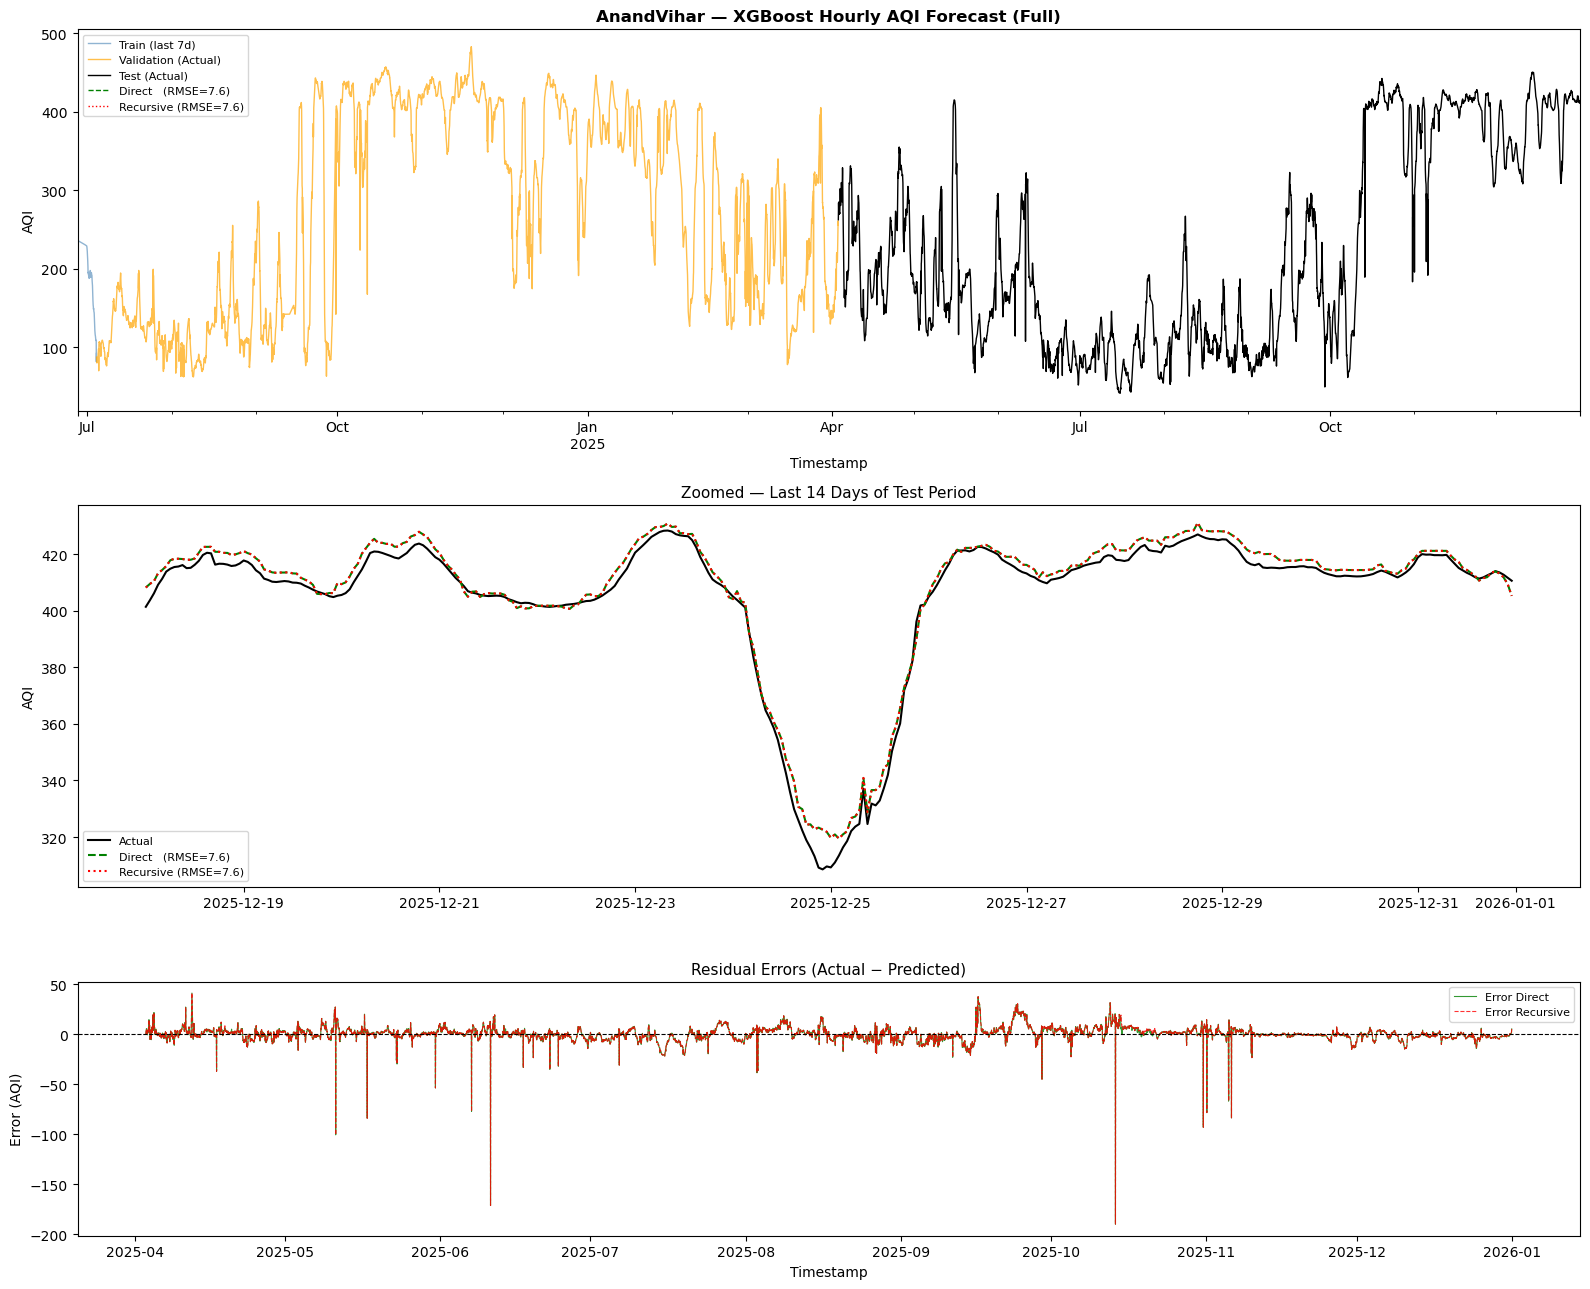

In [9]:
# ── 5c. Plot forecast ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 13), gridspec_kw={'height_ratios': [3, 3, 2]})

# ── Panel 1: Full timeline ──────────────────────────────────
ax = axes[0]
last_train = train_df.set_index('Timestamp')['AQI'].iloc[-168:]
last_train.plot(ax=ax, label='Train (last 7d)', color='steelblue', alpha=0.6, lw=1)

val_ts = val_df.set_index('Timestamp')
val_ts['AQI'].plot(ax=ax, label='Validation (Actual)', color='orange', lw=1.0, alpha=0.7)

test_ts = test_df.set_index('Timestamp')
test_ts['AQI'].plot(ax=ax, label='Test (Actual)', color='black', lw=1.0)
ax.plot(test_ts.index, pred_direct,    label=f'Direct   (RMSE={rmse:.1f})',    color='green', linestyle='--', lw=1.0)
ax.plot(test_ts.index, pred_recursive, label=f'Recursive (RMSE={rmse_r:.1f})', color='red',   linestyle=':',  lw=1.0)

ax.axvline(x=val_df['Timestamp'].iloc[0],  color='gray', linestyle='--', lw=0.8)
ax.axvline(x=test_df['Timestamp'].iloc[0], color='gray', linestyle='-',  lw=0.8)
ax.set_title(f'{STATION_NAME} — XGBoost Hourly AQI Forecast (Full)', fontsize=12, fontweight='bold')
ax.set_ylabel('AQI')
ax.legend(fontsize=8, loc='upper left')

# ── Panel 2: Zoomed — last 14 days of test ─────────────────
ax2 = axes[1]
zoom_n = 14 * 24   # 14 days × 24 hours
test_zoom_idx   = test_ts.index[-zoom_n:]
actual_zoom     = test_ts['AQI'].values[-zoom_n:]
direct_zoom     = pred_direct[-zoom_n:]
recursive_zoom  = pred_recursive[-zoom_n:]

ax2.plot(test_zoom_idx, actual_zoom,    label='Actual',   color='black', lw=1.5)
ax2.plot(test_zoom_idx, direct_zoom,    label=f'Direct   (RMSE={rmse:.1f})',    color='green', linestyle='--', lw=1.5)
ax2.plot(test_zoom_idx, recursive_zoom, label=f'Recursive (RMSE={rmse_r:.1f})', color='red',   linestyle=':',  lw=1.5)
ax2.set_title('Zoomed — Last 14 Days of Test Period', fontsize=11)
ax2.set_ylabel('AQI')
ax2.legend(fontsize=8)

# ── Panel 3: Residual errors ────────────────────────────────
ax3 = axes[2]
errors_direct    = test_ts['AQI'].values - pred_direct
errors_recursive = test_ts['AQI'].values - pred_recursive
ax3.plot(test_ts.index, errors_direct,    label='Error Direct',    color='green', lw=0.8, alpha=0.8)
ax3.plot(test_ts.index, errors_recursive, label='Error Recursive',  color='red',   lw=0.8, alpha=0.8, linestyle='--')
ax3.axhline(0, color='black', lw=0.8, linestyle='--')
ax3.set_title('Residual Errors (Actual − Predicted)', fontsize=11)
ax3.set_ylabel('Error (AQI)')
ax3.set_xlabel('Timestamp')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_forecast_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Feature Importance

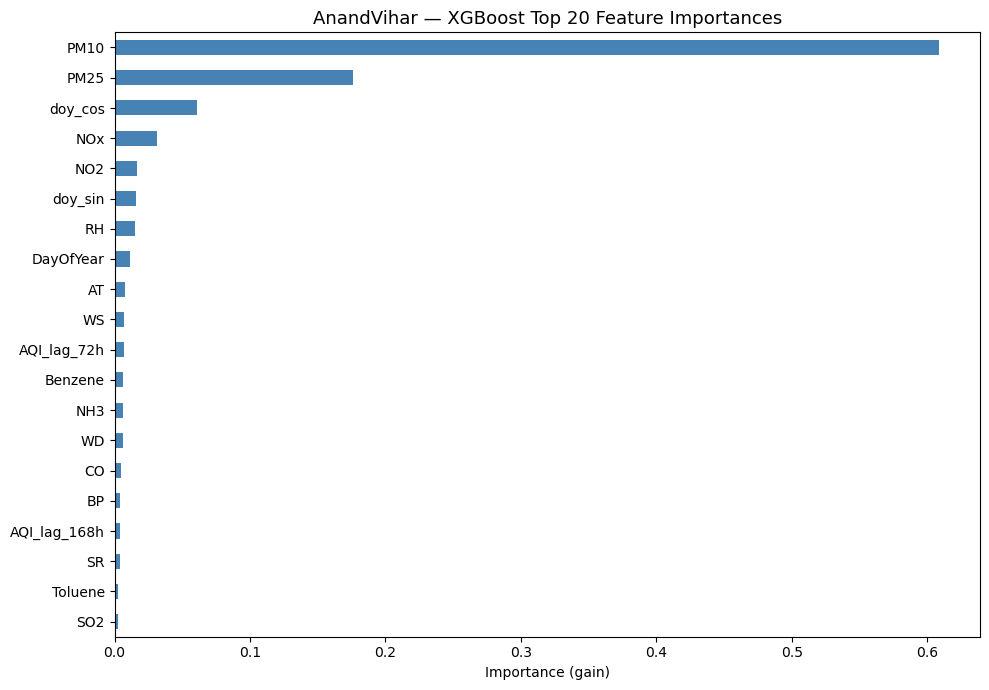


Top 10:
PM10         0.608539
PM25         0.175828
doy_cos      0.060545
NOx          0.031158
NO2          0.016313
doy_sin      0.015990
RH           0.014862
DayOfYear    0.011667
AT           0.007473
WS           0.007305


In [10]:
# ── 6. Feature Importance ─────────────────────────────────────
plt.close('all')
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importance.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title(f'{STATION_NAME} — XGBoost Top 20 Feature Importances', fontsize=13)
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_feature_importance_{STATION_NAME}.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nTop 10:')
print(importance.head(10).to_string())


## 7. Learning Curve

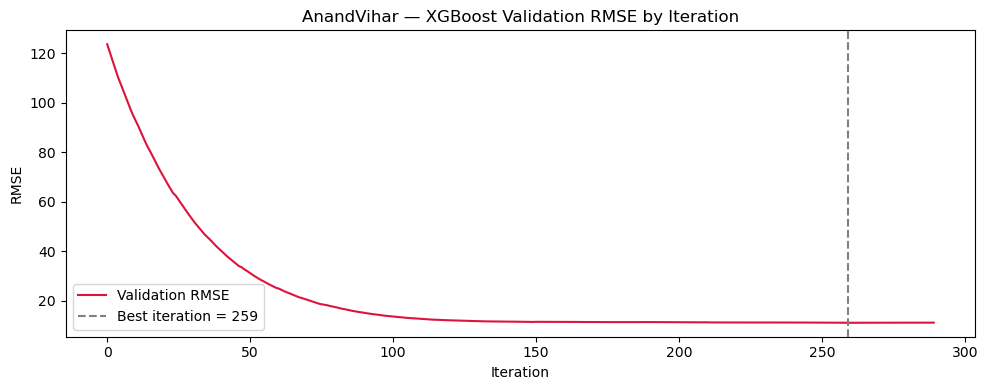

In [11]:
# ── 7. Learning Curve ─────────────────────────────────────────
evals_result = model.evals_result()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(evals_result['validation_0']['rmse'], label='Validation RMSE', color='crimson')
ax.axvline(model.best_iteration, linestyle='--', color='gray',
           label=f'Best iteration = {model.best_iteration}')
ax.set_title(f'{STATION_NAME} — XGBoost Validation RMSE by Iteration')
ax.set_xlabel('Iteration'); ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_learning_curve_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Classification Metrics & Confusion Matrix
Converting continuous AQI forecasts into discrete AQI categories to evaluate classification performance (Accuracy, Precision, Recall).

Classification Metrics for AQI Categories:
Accuracy:  0.9527
Precision: 0.9470 (Weighted)
Recall:    0.9527 (Weighted)

Classification Report:
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        44
Satisfactory       0.91      0.94      0.93      1224
    Moderate       0.96      0.96      0.96      2391
        Poor       0.95      0.97      0.96       845
   Very Poor       0.93      0.97      0.95       747
      Severe       1.00      0.96      0.98      1296

    accuracy                           0.95      6547
   macro avg       0.79      0.80      0.80      6547
weighted avg       0.95      0.95      0.95      6547



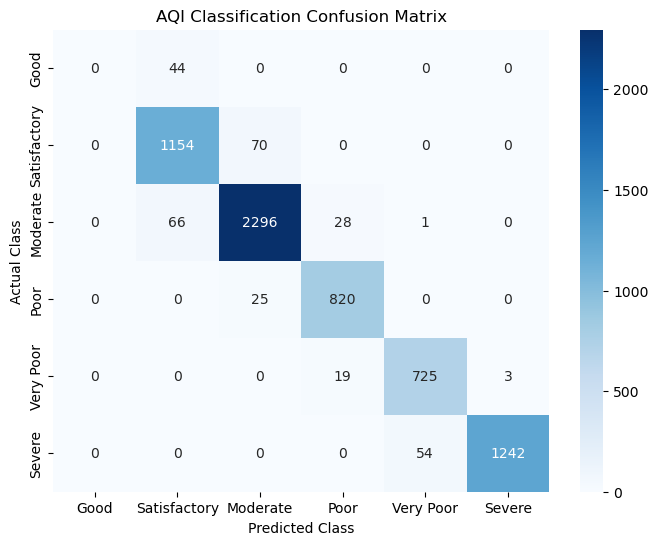

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Define AQI categories based on Indian standards
def categorize_aqi(aqi_values):
    categories = []
    for val in aqi_values:
        if val <= 50:
            categories.append('Good')
        elif val <= 100:
            categories.append('Satisfactory')
        elif val <= 200:
            categories.append('Moderate')
        elif val <= 300:
            categories.append('Poor')
        elif val <= 400:
            categories.append('Very Poor')
        else:
            categories.append('Severe')
    return np.array(categories)

# Ensure values are flattened arrays
y_true_cont = np.array(y_test.values).flatten()
y_pred_cont = np.array(pred_recursive).flatten()

# Convert continuous predictions to discrete AQI classes
y_true_class = categorize_aqi(y_true_cont)
y_pred_class = categorize_aqi(y_pred_cont)

# Labels for standard Indian AQI
labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
# Filter labels to only those present in the actual or predicted to avoid empty rows/cols if desired
# But keeping all labels shows a full matrix
present_labels = [l for l in labels if l in y_true_class or l in y_pred_class]

# Calculate Metrics
acc = accuracy_score(y_true_class, y_pred_class)
# weighted average for precision and recall since it's multiclass
prec = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
rec = recall_score(y_true_class, y_pred_class, average='weighted', zero_division=0)

print(f"Classification Metrics for AQI Categories:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f} (Weighted)")
print(f"Recall:    {rec:.4f} (Weighted)\n")

print("Classification Report:")
print(classification_report(y_true_class, y_pred_class, labels=present_labels, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true_class, y_pred_class, labels=present_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=present_labels, yticklabels=present_labels)
plt.title('AQI Classification Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

os.makedirs('images', exist_ok=True)
plt.savefig(f'{IMAGE_DIR}/xgboost_confusion_matrix_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── 9. Save Model ─────────────────────────────────────────────
import joblib

model_path = os.path.join(SAVE_DIR, f'{STATION_NAME}_xgboost_aqi.pkl')
joblib.dump(model, model_path)
print(f'✅ Model saved : {model_path}')

# Also save feature list so it can be reloaded consistently
import json as _json
feat_path = os.path.join(SAVE_DIR, f'{STATION_NAME}_xgboost_features.json')
with open(feat_path, 'w') as fp:
    _json.dump(feature_cols, fp)
print(f'✅ Feature list: {feat_path}')


✅ Model saved : D:\AQI_Project_new\XGBOOST\saved_models\AnandVihar_xgboost_aqi.pkl
✅ Feature list: D:\AQI_Project_new\XGBOOST\saved_models\AnandVihar_xgboost_features.json
